<a href="https://colab.research.google.com/github/Marcin19721205/WSBNeuronowe/blob/main/CW5Por%C3%B3wnywanie_modeli_12_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wprowadzenie

W ramach tego notebooka zapoznamy się z metodami statystycznego porównywania klasyfikatorów. Żeby uzyskiwane i raportowane wyniki mieściły się w założonych ramach ufności /dokładności, proces należy odpowiednio skonstruować i przestrzegać określonych reguł.
Kolejne sekcje przeprowadzą nas krok po kroku przez odpowiednie narzędzia statystyczne do tego celu.


In [3]:
%pip install tensorflow_addons

ERROR: Could not find a version that satisfies the requirement tensorflow_addons (from versions: none)
ERROR: No matching distribution found for tensorflow_addons


mlxtend to zestaw praktycznych „dodatków” do scikit-learn: daje gotowe, często brakujące w sklearn narzędzia do eksperymentów w ML i analiz danych.

Najczęściej używane rzeczy (konkrety, bez poezji):

Reguły asocjacyjne / market basket
mlxtend.frequent_patterns.apriori, fpmax, association_rules
→ „co kupują razem”, wsparcie, ufność, lift itd.

Selekcja cech (feature selection)
mlxtend.feature_selection.SequentialFeatureSelector
→ forward/backward selection pod dowolny model ze sklearn.

Ensembling / stacking
mlxtend.classifier.StackingClassifier (i regresor)
→ sklejanie kilku modeli w jeden (meta-model).

Ocena modeli / macierze błędów / wykresy
np. plot_confusion_matrix, plot_decision_regions
→ szybkie wizualizacje, głównie edukacyjno-debugowe.

In [4]:
%pip install mlxtend

scikit-posthocs robi jedną, bardzo konkretną robotę: testy post-hoc, czyli „które pary grup różnią się między sobą” po tym, jak test globalny (ANOVA / Kruskal–Wallis / Friedman) powiedział Ci „coś jest nie tak”.

Co dostajesz w praktyce:

porównania parami (grupa A vs B, A vs C, …) jako macierz p-value

popularne testy post-hoc:

po Kruskal–Wallis: np. Dunn, Conover

po Friedmanie (powtarzane pomiary): np. Nemenyi

po ANOVA: też ma warianty, ale najczęściej ludzie używają go właśnie do nieparametrycznych

korekty na wielokrotne porównania: Holm, Bonferroni, FDR (żebyś nie „udowodnił” różnic wszędzie przez przypadek)

Krótko: to jest „młotek” do szukania konkretnie których różnic między grupami, gdy globalny test już krzyknął, że różnice istnieją.

In [5]:
%pip install scikit_posthocs

In [7]:
%pip install scikeras
# Instaluje SciKeras – adapter, który pozwala używać modeli Keras/TensorFlow jak estymatorów scikit-learn (fit/predict, Pipeline, GridSearchCV).

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow.keras as kk
import scikeras.wrappers as sk_wrappers
#import tensorflow_addons as tfa
import scipy.stats as st
import scikit_posthocs as sp
from mlxtend.evaluate import mcnemar, mcnemar_table, f_test, mcnemar_tables

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

from sklearn.metrics import classification_report, f1_score, make_scorer

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

<div class='alert alert-block alert-danger'>
<b>Uwaga</b>, celem niniejszego ćwiczenia <b>nie jest</b> "podkręcenie" za wszelką cenę parametrów każdego z analizowanych klasyfikatorów. Głównym zadaniem jest zapoznanie się z metodami porównywania ich ze sobą. Z tego względu - niektóre algorytmy będą używane z domyślnymi parametrami, a sieć neuronowa nie będzie optymalizowana pod kątem architektury. Niepotrzebnie odciągałoby to naszą uwagę od najważniejszego tematu.
    
<br>
Po przejściu głównej części ćwiczenia, możesz kontynuować takie eksperymenty we własnym zakresie, w tym samym notebooku.
</div>

# Przygotowanie danych

Będziemy pracować na niezbalansowanym zbiorze danych, szkoląc kilka różnych modeli.


<div class='alert alert-block alert-warning'>
    <b>Zadanie</b>:
    <ol>
        <li>Wczytaj zbiór danych o nazwie <code>dataset_compare_classifiers.csv</code></li>
        <li>Podziel zbiór na X i y, poprzez wydzielenie kolumny "y"</li>
        <li>Ze względu na kompatybilność z Tensorflow - zamień typ zmiennej X na <code>np.float32</code></li>
        <li>
            Podziel zbiór na częśc testową i treningową, wykorzystując następujące ustawienia:
            <ol>
                <li>[%] danych treningowych = 80</li>
                <li>random_state = 123 (ma zapewnić powtarzalność eksperymentów)</li>
            </ol>
        </li>
    </ol>
</div>

Zbiór danych znajduje się pod adresem: `https://drive.google.com/uc?id=1U5_R3K-n7ulg35OemltkQXR-Gq6uoDv9&export=download`

In [10]:
data = pd.read_csv("https://drive.google.com/uc?id=1U5_R3K-n7ulg35OemltkQXR-Gq6uoDv9&export=download")
X, y = data.drop(columns=['y']), data.y #Podziel zbiór na X i y, poprzez wydzielenie kolumny "y"
X = X.astype(np.float32) #zamień typ zmiennej X na np.float32

wyświetl strukturę danych

In [11]:
# --- struktura całego DataFrame ---
print("data.shape:", data.shape)          # liczba wierszy i kolumn
print("\ndata.dtypes:\n", data.dtypes)    # typy kolumn
display(data.head())                      # pierwsze wiersze
data.info()                               # info: typy + braki danych + pamięć

# --- struktura X i y ---
print("\nX.shape:", X.shape)              # wymiary macierzy cech
print("y.shape:", y.shape)                # wymiary wektora celu
print("\nX dtypes (unikalne):", X.dtypes.unique())  # typy w X (po astype powinien być float32)
print("\ny dtype:", y.dtype)              # typ y

# --- szybki sanity-check ---
print("\nBraki danych (data):\n", data.isna().sum())  # liczba NaN w kolumnach
print("\nRozkład klas / wartości y:\n", y.value_counts(dropna=False))  # ile czego w y


data.shape: (5000, 31)

data.dtypes:
 feature_1     float64
feature_2     float64
feature_3     float64
feature_4     float64
feature_5     float64
feature_6     float64
feature_7     float64
feature_8     float64
feature_9     float64
feature_10    float64
feature_11    float64
feature_12    float64
feature_13    float64
feature_14    float64
feature_15    float64
feature_16    float64
feature_17    float64
feature_18    float64
feature_19    float64
feature_20    float64
feature_21    float64
feature_22    float64
feature_23    float64
feature_24    float64
feature_25    float64
feature_26    float64
feature_27    float64
feature_28    float64
feature_29    float64
feature_30    float64
y               int64
dtype: object


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,y
0,0.106980,-0.266248,-0.100403,-1.282091,0.340059,-1.422818,0.056434,1.099825,2.688278,-0.001570,...,-0.026928,-0.871325,-1.464032,0.363961,-1.466826,-0.702146,0.563066,2.570533,-0.526953,0
1,0.968466,-0.095616,1.156955,1.579614,-1.039149,0.180087,0.158164,-1.927135,0.966504,-1.596583,...,-0.101014,0.705218,-0.443436,0.110776,1.722701,-0.318866,0.062147,0.020332,0.284570,0
2,0.494982,-0.329678,1.098432,1.727399,-2.000378,-1.674113,1.353196,-0.829409,-0.334496,-1.689082,...,0.048330,1.400489,0.297162,-1.770923,0.728331,0.294293,0.431104,-1.516850,-0.084470,0
3,-0.879221,0.911699,0.928299,-0.029951,2.022062,0.451950,0.377553,3.648325,-1.618281,1.057396,...,1.400845,-0.428884,-2.889422,-0.028083,-2.320107,-0.216005,0.257566,-1.394136,-0.256045,2
4,1.096030,0.189990,0.859307,-2.078332,2.955702,-1.458639,-0.432909,-1.132350,0.504120,0.397450,...,-0.451383,0.101181,0.368589,-1.746804,-1.021504,1.124922,2.114285,-0.196487,0.537690,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   feature_1   5000 non-null   float64
 1   feature_2   5000 non-null   float64
 2   feature_3   5000 non-null   float64
 3   feature_4   5000 non-null   float64
 4   feature_5   5000 non-null   float64
 5   feature_6   5000 non-null   float64
 6   feature_7   5000 non-null   float64
 7   feature_8   5000 non-null   float64
 8   feature_9   5000 non-null   float64
 9   feature_10  5000 non-null   float64
 10  feature_11  5000 non-null   float64
 11  feature_12  5000 non-null   float64
 12  feature_13  5000 non-null   float64
 13  feature_14  5000 non-null   float64
 14  feature_15  5000 non-null   float64
 15  feature_16  5000 non-null   float64
 16  feature_17  5000 non-null   float64
 17  feature_18  5000 non-null   float64
 18  feature_19  5000 non-null   float64
 19  feature_20  5000 non-null  

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=123)
# Dzieli dane na trening (80%) i test (20%) losowo, ale powtarzalnie dzięki stałemu random_state.

Sprawdzenie poprawności wyniku:

In [13]:
X_test.shape

(1000, 30)

In [14]:
assert X_train.shape == (4000, 30)
assert X_test.shape == (1000, 30)
assert y_train.shape == (4000, )
assert y_test.shape == (1000, )

In [27]:
y_test.describe()


,y
count,1000.000000
mean,0.589000
std,0.797945
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,2.000000


# Dwa modele sieci neuronowych

Pierwszym krokiem będzie przygotowanie spójnego środowiska do eksperymentów. W tym celu będziemy potrzebować:

1.	Funkcji budujących i zwracających odpowiednie sieci neuronowe.
2.	Narzędzia służącego do spójnego i jednakowego dzielenia zbioru danych na części w k-krotnej walidacji krzyżowej.
3. Przygotowanie metryki.
4.	Przeprowadzanie eksperymentu i zebranie metryk.
5. Analiza zebranych metryk i ich porównanie.
6. Porównanie na zbiorze testowym.

## Krok 1. - Funkcje budujące sieci

**Zadanie**:

Uzupełnij implementację funkcji budującej sieć neuronową.


Funkcja przyjmuje parametr `normalize=True`. Jeśli jego wartość `= True`: **dodaj jako drugą warstwę sieci**, `keras.layers.BatchNormalization()`. W przeciwnym wypadku: nie dodawaj takiej warstwy.


Struktura sieci musi wyglądać następująco:
1. Pierwsza warstawa `Input(input_shape=(X_train.shape[1],))` - odpowiada za wejście do sieci, równe ilości cech w zbiorze.
2. (Opcjonalnie) warstwa `BatchNormalization` jeśli przekazano parametr.
3. Kolejne warstwy gęste (typ - liczba jednostek - aktywacja):
    3. `Dense, 32, relu`
    4. `Dense 16 relu`
    5. `Dense, 8, relu`
6. `Dense 3, softmax` - dokonująca klasyfikacji

_______________

**UWAGA** wyjątkowo - **nie kompiluj modelu**. Tym zajmie się biblioteka **scikeras**, którą wykorzystamy potem do walidacji krzyżowej.

_______________

Dla zapewnienia powtarzalności eksperymentu na samym począku funkcji wywołaj dwa polecenia, które ustawią generatory liczb losowych `np.random.seed(123)` oraz `tf.random.set_seed(456)`

In [15]:
def build_network(normalize=True):
    np.random.seed(123)                                # powtarzalne wyniki
    tf.random.set_seed(456)                            # ziarna losowości

    inputs = kk.Input(shape=(X_train.shape[1],))       # Warstwa wejściowa
    x = inputs

    if normalize:
        x = kk.layers.BatchNormalization()(x)          # Normalizacja cech

    x = kk.layers.Dense(32, activation='relu')(x)
    x = kk.layers.Dense(16, activation='relu')(x)
    x = kk.layers.Dense(8, activation='relu')(x)
    outputs = kk.layers.Dense(3, activation='softmax')(x)  # Warstwa wyjściowa – 3 klasy

    model = kk.Model(inputs=inputs, outputs=outputs)   # Złożenie modelu w API funkcyjnym Keras
    return model                                       # Zwrócenie gotowego modelu


Sprawdzenie poprawności wyniku

In [16]:
network1 = build_network()
network2 = build_network(False)

In [17]:
def check_network_params(network_layers, expected_specs):
    for actual_l, (expected_type, expected_size, expected_act) in zip(network_layers, expected_sizes_types_activations):
        assert isinstance(actual_l, expected_type)
        assert actual_l.units == expected_size
        assert actual_l.activation == expected_act


expected_sizes_types_activations = [
    (kk.layers.Dense, 32, kk.activations.relu),
    (kk.layers.Dense, 16, kk.activations.relu),
    (kk.layers.Dense, 8, kk.activations.relu),
    (kk.layers.Dense, 3, kk.activations.softmax)
]

# For network1 (with normalization)
assert isinstance(network1.layers[0], kk.layers.InputLayer)
assert isinstance(network1.layers[1], kk.layers.BatchNormalization)
check_network_params(network1.layers[2:], expected_sizes_types_activations)

# For network2 (without normalization)
assert isinstance(network2.layers[0], kk.layers.InputLayer) #
check_network_params(network2.layers[1:], expected_sizes_types_activations)

## Krok 2 - spójny podział danych

W sklearn istnieje możliwość przygotowania obiektu służącego dzieleniu danych podczas k-kroktnej walidacji krzyżowej w sposób spójny, tzn. zawsze tak samo dla każdego modelu. Dzięki temu zachodzi możliwość porównywania ze sobą modeli pomiędzy eksperymentami.

<div class='alert alert-block alert-warning'>
<b>Zadanie</b>: Utwórz obiekt typu <code>StratifiedKFold</code>, przekazując parametry:

<ol>
<li>Random_state=123 – zapewni powtarzalność podziału</li>
<li>Shuffle=True – zmiana kolejności danych pomiędzy iteracjami </li>
<li>N_splits = 10 - do przeprowadzenia 10-o kroktnej walidacji krzyżowej</li>
</ol>

Ten obiekt, podczas każdego podziału k-krotnej walidacji krzyżowej, odzwierciedla proporcje klas w całym zbiorze.
</div>

In [19]:
splitter = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)
# Tworzy 10-fold CV ze stratyfikacją (te same proporcje klas w foldach) i losowym tasowaniem powtarzalnym dzięki random_state.

Sprawdzenie poprawności wyniku:

In [20]:
idx_tr, idx_val = next(splitter.split(X_train, y_train))
yfold_tr, yfold_val = y_train.iloc[idx_tr], y_train.iloc[idx_val]
assert all(np.round(yfold_val.value_counts(normalize=True), 2) == np.round(yfold_tr.value_counts(normalize=True), 2))

## Krok 3 - przygotowanie metryki

W sklearn, do automatycznego prowadzenia k-krotnej walidacji krzyżowej potrzebny jest obiekt typu <code>scorer</code>. Ze względu na fakt, że w tym ćwiczeniu mamy do czynienia z nierównowagą klas, powinniśmy użyć metryki F1-score.
Niestety, nie można jej przekazać bez wstępnej konfiguracji. Dla wielu klas, trzeba określić sposób uśredniania metryki F1. W tym celu:

<div class='alert alert-block alert-warning'>
    <b>Zadanie</b>:
    <ol>
        <li>Zaimplementuj własną funkcję, która przyjmuje <code>y_true</code> - wartości oczekiwane oraz  <code>y_pred</code> - wartości przewidziane przez model. </li>
        <li>Funkcja wywołuje <code>f1_score</code> z pakietu sklearn, przekazując mu te same parametry oraz dodatkowo <code>average=’macro’</code>.</li>
        <li>Utwórz obiekt typu <code>scorer</code> wywołując funkcję <code>make_scorer(…)</code> na swojej funkcji.
</li>
    </ol>
</div>





In [21]:
def f1_macro_scorer(y_true, y_pred):
    return f1_score(y_true, y_pred, average='macro')

f1scorer = make_scorer(f1_macro_scorer)

Sprawdzenie poprawności wyniku

In [22]:
dc = DummyClassifier(strategy='most_frequent')
dc.fit(X_train, y_train)

assert np.round(f1_macro_scorer([0, 0, 1, 1, 2, 2], [0, 0, 1, 0, 2, 1]), 2) == 0.66
assert np.round(f1scorer(dc, X_train, y_train), 2) == 0.25

## Krok 4 - przeporwadzenie eksperymentu

Teraz mamy wszystkie składniki niezbędne do przeprowadzenia porównania dwóch sieci neuronowych.

<div class='alert alert-block alert-warning'>
    <b>Zadanie</b>:
    <ol>
        <li>Zbuduj dwie sieci, wykorzystując wcześniej napisaną funkcję i "opakowując" ją w <code>sk_wrappers.KerasClassifier</code> (<a href='https://www.adriangb.com/scikeras/stable/index.html'>biblioteka scikieras odpowiedzialna za konwersję sieci w Kerasie na sklearn)</a>:</li>
         <ol>
             <li>Sieć z normalizacją, do obiektu <code>KerasClassifier</code> przekaż parametry <code>normalize=True, epochs=15, batch_size=32, verbose=0, loss='sparse_categorical_crossentropy' </code></li>
             <li>Sieć bez normalizacji, do obiektu <code>KerasClassifier</code> przekaż parametry <code>normalize=False, epochs=15, batch_size=32, verbose=0, loss='sparse_categorical_crossentropy' </code></li>
        </ol>
        <li>Zbierz metryki f1 z 10-o krotnej walidacji krzyżowej, uruchamiając funkcję <code>cross_val_score</code> i przekazując:</li>
             <ol>
                 <li>Odpowiednią sieć neuronową "opakowaną" we wrapper jako estymator</li>
                 <li>Dane treningowe X_train, y_train</li>
                 <li><code>scorer=f1scorer</code> - przygotowany wcześniej obiekt liczący metrykę</li>
                 <li><code>cv=splitter</code> - przygotowany wcześniej obiekt służący do spójnego dzielenia danych metodą Stratified K-fold</li>
            </ol>
    </ol>
</div>


___________

**CIEKAWOSTKA** Funkcja kosztu `sparse_categorical_crossentropy` jest używana w sytuacji, gdy:
1. Dokonujemy klasyfikacji wieloklasowej
2. Sieć neuoronowa zwraca wektor one-hot dla klas
3. Wartości oczekiwane y są określone numerami klas, a nie one hot.

> Przykład:  
Mamy trzy klasy A,B,C
Model zwraca wynik jako one-hot:  
```
0-0-1  
0-1-0  
1-0-0
```  
Tymczasem klasy oczekiwane $y$ sa zakodowane numerycznie jako 1,2,3.  
Takie podejście oszczędza pamięć (bo nie trzeba alokować dużej macierzy dly-ków)



In [23]:
model1_nn = sk_wrappers.KerasClassifier(model=build_network, normalize=True, epochs=15, batch_size=32, verbose=0, loss='sparse_categorical_crossentropy')
model2_nn = sk_wrappers.KerasClassifier(model=build_network, normalize=False, epochs=15, batch_size=32, verbose=0, loss='sparse_categorical_crossentropy')

In [24]:
model1_cv_scores = []
model2_cv_scores = []

for train_index, val_index in splitter.split(X_train, y_train):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # normalization
    model1_nn_fold = sk_wrappers.KerasClassifier(model=build_network, normalize=True, epochs=10, batch_size=32, verbose=1, loss='sparse_categorical_crossentropy')
    model1_nn_fold.fit(X_train_fold, y_train_fold)
    y_pred_val1 = model1_nn_fold.predict(X_val_fold)
    score1 = f1_macro_scorer(y_val_fold, y_pred_val1)
    model1_cv_scores.append(score1)

    # bez normalizacji
    model2_nn_fold = sk_wrappers.KerasClassifier(model=build_network, normalize=False, epochs=10, batch_size=32, verbose=1, loss='sparse_categorical_crossentropy')
    model2_nn_fold.fit(X_train_fold, y_train_fold)
    y_pred_val2 = model2_nn_fold.predict(X_val_fold)
    score2 = f1_macro_scorer(y_val_fold, y_pred_val2)
    model2_cv_scores.append(score2)

model1_cv = np.array(model1_cv_scores)
model2_cv = np.array(model2_cv_scores)

Epoch 1/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0950
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8811
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7961
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7430
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7052
Epoch 6/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6729
Epoch 7/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6447
Epoch 8/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6195
Epoch 9/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5978
Epoch 10/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5772
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Epoch 1/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.9926
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.8219
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7416
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6840
Epoch 5/10
113/113 ━━

<div class='alert alert-block alert-warning' >
    Narysuj wykres pudełkowy obu wyników klasyfikacji.
</div>

/tmp/ipython-input-3300995128.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  boxplot.set_xticklabels(['Model 1 -bez norm.', 'Model 2 - norm.']);


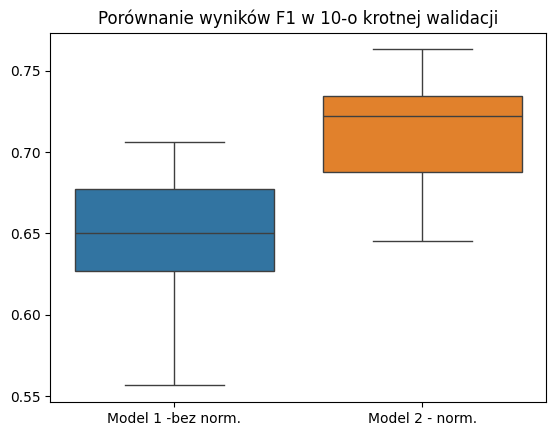

In [25]:
boxplot = sns.boxplot(data=[model1_cv, model2_cv])
boxplot.set_title('Porównanie wyników F1 w 10-o krotnej walidacji')
boxplot.set_xticklabels(['Model 1 -bez norm.', 'Model 2 - norm.']);

<div class='alert alert-block alert-info' >
    Zastanów sie nad uzyskanymi wynikami? Czy wynika z nich, który klasyfikator jest lepszy? Który bardziej stabilny? Zastanów się nad tym, a podsumwanie wniosków znajdziesz poniżej (zwinięte pod trzema kropkami).
</div>

Z przedstawionych wykresów możemy "na oko" wywnioskować co najmniej dwie rzeczy:
1. Mediana metryki F1 wydaje się wyższa dla modelu z normalizacją.
2. Rozstęp międzykwartylowy dla klasyfikatora bez noralizacji jest znacznie większy - sugeruje to jego małą stabilność (dużą wariancję).

Takich rzeczy nie ocenia się natomiast "na oko", potrzebny jest test statystyczny, który potwierdzi, czy oba modele sprawują się podobnie/lepiej lub gorzej.

## Krok 5 - porównanie otrzymanych metryk i wyników

W tym przypadku mamy do czynienia z porównaniem dwóch wektorów wartości numerycznych – wyników metryki F1 dla danych walidacyjnych, dla dwóch klasyfikatorów.
Możemy przeanalizować te dane na co najmniej trzy sposoby:

1. **T-test różnicy średnich** – parametryczny test, przeznaczony dla **niezależnych** próbek. Przy zastosowaniu walidacji krzyżowej zachodzi wątpliwość, czy próbki są naprawdę niezależne. Z punktu widzenia metodologii, nie jest to całkiem poprawne podejście.
2. **Test korelacji rang Wilcoxona** – nieparametryczny test korelacji rang WIlcoxona. Nie ma tak silnych założeń, jak T-test. Ma co prawda mniejszą moc (może nie wykryć różnicy, jeśli jest mała), ale jest polecany jako narzędzie do testowania tego rodzaju wartości. Jednym z założeń tego testu jest zbliżony rozkład w obu próbkach. Czasem możemy nie być pewni, czy taka zależność zachodzi.
3. **Test Manna-Whitneya** – nieparametryczny test korelacji rang, zbliżony do testu Wilcoxona. Nie zakłada w żaden sposób rozkładu którejkolwiek z próbek. Z tego testu powinno się korzystać, gdy liczność każdej z próbek > 20-30 obserwacji.

W przypadku wszystkich trzech testów, mamy następujące, hipotezy:
- **Hipoteza zerowa** - nie zachodzi istotna różnica średniej wartości metryki F1 pomiędzy modelami.
- **Hipoteza alternatywna** - zachodzi istotna różnica średniej wartości metryki F1 pomiędzy modelami.

Testy będziemy przeprowadzać na poziomie istotnoci alpha = 0.05. Uzyskanie w teście p-wartości na poziomie < 0.05 pozwala **odrzucić hipotezę zerową**.


<div class='alert alert-block alert-warning' >
    <b>Zadanie</b>: wykorzystaj funkcję <code>wilcoxon(...)</code> z pakietu <code>scipy.stats</code> do praprowadzenia testu istotności dwóch wektorów. <b>Zapisz p-value</b>. Zapoznaj się z dokumentacją i wyjaśnieniem działania testu na stronie <a href=https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.wilcoxon.html#scipy.stats.wilcoxon>pakietu</a>.
</div>

In [28]:
stat, pval = st.wilcoxon(model1_cv, model2_cv)

Sprawdzenie poprwaności wyniku:

In [32]:
assert pval < 0.05

<div class='alert alert-block alert-info' >
    Co w przedstawionym kontekście oznacza pval < 0.05?
</div>

**Odpowiedź:** Zachodzą podstawy do odrzucenia hipotezy zerowej, że nie ma różnicy w wartości metryki F1 pomiędzy klasyfikatorami.

W tej sytuacji uznajemy, że klasyfikator wykrzystujący normalizację rzeczywiście uzyskuje lepsze wyniki i to właśnie jego będziemy wykorzystywać w dalszych eksperymentach.

## Krok 6 - porównanie na zbiorze testowym

Wcześniej porównywaliśmy treningowe wartości walidacji krzyżowej. Tym razem będziemy porównywać wyniki na jednym zbiorze - testowym, bez sprawdzania wielokrotnego. Do tego celu możemy wykorzystać test **McNemara**, który buduje tabelę pomyłek i bada istotność różnic za pomocą statystyki $\chi^2$.

Proces budowania statystyki McNemara wygląda nastęująco:
1. Pierwszy klasyfiktor dokonuje predykjci
2. Drugi klasyfikator dokonuje predykcji
3. Porównywane jest, dla których przykładów klasyfikator 1 i 2 dokonały błędnej oceny.
4. Porównaie jest umieszczane w tabeli, w której wyszczególnione jest, ile razy pomylił się klasyfiaktor 1, ile razy 2, a ile razy oba łącznie.
5. Na podastawie tak otrzymanej tabeli - wyliczana jest statystyka $\chi^2$

<img src='https://drive.google.com/uc?id=1TtOTWS7zpxVSf8QIsdWUPnBXh4DV7CfW&export=download' />

$$
\chi^2_{mcNemar} = \frac{\left(|b-c| - 1 \right)^2}{(b+c)}
$$

- **Hipoteza zerowa** - nie zachodzi istotna różnica w wynikach predykcji na zbiorze testowym.
- **Hipoteza alternatywna** - zachodzi istotna różnica w wynikach predykcji na zbiorze testowym.

<div class='alert alert-block alert-warning' >
<b>Zadanie</b>:
<ol>
<li>Zbuduj ponownie oba modele</li>
<li>Dokonaj kompilacji (tym razem nie używamy biblioteki scikeras) poleceniami <code>MODEL.compile(loss='sparse_categorical_crossentropy', optimizer='adam')</code></li>
<li>Wyszkol je na <b>całym</b> zbiorze treningowym - liczba epok=10, batch size=32</li>
<li>Dokonaj predykcji na zbiorze testowym za pomocą funkcji <code>predict</code>, która zwraca prawdopodobieństwo przynależności do każdej klasy (z wyników softmax), a następnie wywołaj <code>.argmax(axis=1)</code> by pobrać klasę o najwyższym prawdopodobieństwie</li>
<li>Porównaj wyniki predykcji za pomocą statystki McNemara z biblioteki Mlxtend. Opis i dokumentację odpowiedniej funkcji znajdziesz <a href="http://rasbt.github.io/mlxtend/user_guide/evaluate/mcnemar/">na oficjalnej stronie biblioteki, w dokumentacji</a>
<ol>
    <li>Najpierw zbuduj tablę McNemara funkcją <code>mcnemar_table</code></li>
    <li>Zbudowaną tabelę, przekaż do funkcji <code>mcnemar</code></li>
    <li>Wyświetl otrzymaną tabelę i zastanów się nad wynikami.</li>
</ol>


</li>
</ol>
</div>

In [33]:
model1 = build_network(normalize=True)
model1.compile(loss='sparse_categorical_crossentropy', optimizer='adam')

model2 = build_network(normalize=False)
model2.compile(loss='sparse_categorical_crossentropy', optimizer='adam')

In [34]:
model1.fit(X_train, y_train, epochs=15, batch_size=32, verbose=1)
model2.fit(X_train, y_train, epochs=15, batch_size=32, verbose=1)

yhat_test_model1 = model1.predict(X_test).argmax(axis=1)
yhat_test_model2 = model2.predict(X_test).argmax(axis=1)

Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.0800
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8540
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7935
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7433
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7000
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6571
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6173
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5828
Epoch 9/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5526
Epoch 10/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5276
Epoch 11/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5057
Epoch 12/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4859
Epoch 13/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4684
Epoch 14/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4527
Epoch 15/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

Najpierw zbuduj tablę McNemara funkcją mcnemar_table
Zbudowaną tabelę, przekaż do funkcji mcnemar
Wyświetl otrzymaną tabelę i zastanów się nad wynikami.

In [36]:
model12_table = mcnemar_table(y_test, yhat_test_model1, yhat_test_model2)
chi2_mcnemar, pval_mcnemar = mcnemar(model12_table)
print(model12_table)
print(f"Chi2 statistic: {chi2_mcnemar:.4f}")
print(f"P-value: {pval_mcnemar:.4e}")

[[760  50]
 [ 59 131]]
Chi2 statistic: 0.5872
P-value: 4.4352e-01


<div class='alert alert-block alert-info' >
Co w przedstawionym konteście oznacza otrzymane pvalue?    
</div>

# Porównywanie wielu klasyfikatorów

Kolejnym etapem ćwiczenia będzie wykonanie porównania więcej niż dwóch klasyfikatorów. Kroki będą zbliżone jak w poprzedniej części:

1. Przygotowanie (zbudowanie) klasyfikatorów.
2. Przeprowadzenie 10-o krotnej walidacji krzyżowej z użyciem funkcji scoringowej i podziału
4. Porównanie wyników (ogółem).
5. Porównanie wyników poszczególnych klasyfikatorów.

--------------

<div class='alert alert-block alert-warning'>

Utwórz trzy kolejne klasyfikatory
1.	Random Forest
2.	Regresja logistyczna
3.	Naiwny klasyfikataor bayesowski
Powtórz eksperyment z 10-o krotną walidacją krzyżową dla każdego z czterech klasyfikatorów.


Zbierz metryki f1 z 10-o krotnej walidacji krzyżowej, uruchamiając funkcję <code>cross_val_score</code> i przekazując:
             <ol>
                 <li>
                     Utwórz cztery klasyfikatory:
                     <ol>
                         <li>Random Forest - z domyślnymi parametrami</li>
                         <li>LogisticRegression- z domyślnymi parametrami</li>
                         <li>KNeighborsClassifier - z domyślnymi parametrami</li>
                         <li>Sieć neuronową z normalizacją, wykorzystując wcześniej przygotowaną funkcję do budowania, przekazaną do obiektu <code>KerasClassifier</code> z parametrami <code>normalize=True, epochs=10, batch_size=32, verbose=0, loss='sparse_categorical_crossentropy'</code></li>
                     </ol>
                </li>
                 <li>Każdy z czeterech klasyfikatorów przekaż do funkcji <code>cross_val_score</code> dodając:
                     <ol>
                         <li>Dane treningowe X_train, y_train</li>
                         <li><code>scorer=f1scorer</code> - przygotowany wcześniej obiekt liczący metrykę</li>
                         <li><code>cv=splitter</code> - przygotowany wcześniej obiekt służący do spójnego dzielenia danych metodą Stratified K-fold</li>
                     </ol>        
                </li>
                <li>Wyniki zapisz jako <code>pd.DataFrame</code> z nazwami kolumn odpowiadającymi klasyfikatorom: <code>Random Forest, Logistic Regression, KNN, NN</code></li>
    <li>Narysuj wykres pudełkowy (ang. <i>boxplot</i>) rozrzutu wyników</li>
            </ol>
</div>

## Krok 1 - utworzenie klasyfikatorów

In [37]:
clf1 = RandomForestClassifier(random_state=123) # Added random_state for reproducibility
clf2 = LogisticRegression(random_state=123) # Added random_state for reproducibility
clf3 = KNeighborsClassifier()

## Krok 2 - zebranie metryk

In [39]:
clf1_cv = cross_val_score(clf1, X_train, y_train, scoring=f1scorer, cv=splitter)
clf2_cv = cross_val_score(clf2, X_train, y_train, scoring=f1scorer, cv=splitter)
clf3_cv = cross_val_score(clf3, X_train, y_train, scoring=f1scorer, cv=splitter)

nn_cv_scores = []
nn_wrapper = sk_wrappers.KerasClassifier(model=build_network, normalize=True, epochs=15, batch_size=32, verbose=1, loss='sparse_categorical_crossentropy')

for train_index, val_index in splitter.split(X_train, y_train):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # For model 1 (with normalization)
    # Corrected verbose to 0 for consistency
    model_nn_fold_temp = sk_wrappers.KerasClassifier(model=build_network, normalize=True, epochs=10, batch_size=32, verbose=0, loss='sparse_categorical_crossentropy')
    model_nn_fold_temp.fit(X_train_fold, y_train_fold)
    y_pred_val = model_nn_fold_temp.predict(X_val_fold)
    score = f1_macro_scorer(y_val_fold, y_pred_val)
    nn_cv_scores.append(score)

nn_cv = np.array(nn_cv_scores)

In [40]:
cv_results = {
    'Random Forest': clf1_cv,
    'Logistic Regression': clf2_cv,
    'KNN': clf3_cv,
    'NN': nn_cv
}
cv_scores_df = pd.DataFrame.from_dict(cv_results)

Sprawdzenie poprawności wyniku:

In [41]:
for name in ['Random Forest', 'Logistic Regression', 'KNN', 'NN']:
    assert name in cv_scores_df.columns

In [42]:
assert cv_scores_df.shape == (10, 4)

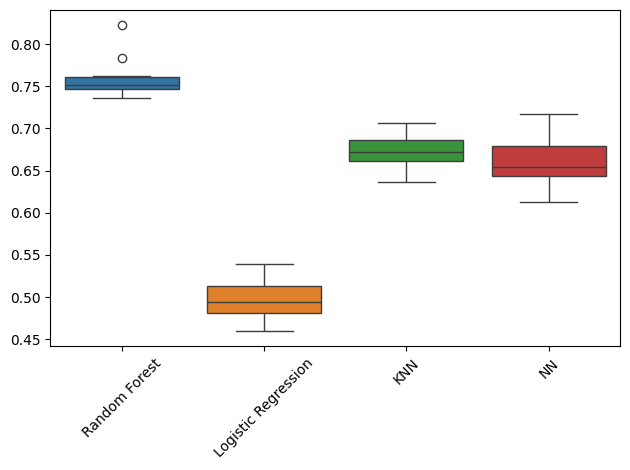

In [43]:
sns.boxplot(data=cv_scores_df)
plt.xticks(rotation=45)
plt.tight_layout()

## Krok 3 - porównanie metryk ogółem

Aby sprawdzić, czy <b>pomiędzy wszystkimi klasyfikatorami, ogółem</b> zachodzi różnica w istotności wyników – przeprowadzimy <b>nieparametryczny test Friedmana</b>. Jest to nieparametryczny odpwoiednik ANOVY, służący do sprawdzania istotności różnic pomiędzy wieloma grupami.

- **Hipoteza zerowa** - nie zachodzi istotna różnica w średnich wartościach metryki F1, podczas 10-o krotnej walidacji krzyżowej pomiędzy klasyfikatorami.
- **Hipoteza alternatywna** - co najmniej jeden z klasyfikatorów istotnie różni się od pozostałych średnią wartością metryki F1 w 10-o krotnej walidacji krzyżowej.


<div class='alert alert-block alert-warning' >
    Wywołaj funkcję <code>friedmanchisquare</code>, przekazując wektory wyników poszczególnych klasyfikatorów. Zapisz uzyskane p-value.
</div>

In [44]:
stat, pval = st.friedmanchisquare(*cv_results.values())

In [45]:
stat, pval

(np.float64(27.47999999999999), np.float64(4.669409820165777e-06))

Sprawdzenie poprawności wyniku:

<div class='alert alert-block alert-info' >
    Co w przedstawionym kontekście oznacza pvalue?
</div>

## Krok 4: porównanie wyników pomiędzy poszczególnymi klasyfikatorami - walidacja krzyżowa

Teraz, kiedy wiemy, że co najmniej jeden klasyfikator się wyróżnia na tle pozostałych, należy sprawdzić, o który klasyfikator chodzi.


W tym celu wykonuje się tzw. <b>porównania post-hoc (ang. Post-hoc testing)</b> . Zasada jest prosta – sprawdza się klasyfikatory parami, na zasadzie każdy-z-każdym, badając, czy zachodzą różnice. Istotne jest, to, że wszystkie porównania <b>łącznie</b> utrzymywane są na poziomie istotności 0.05: każdy pojedynczy test jest przeprowadzany na poziomie istotności zapewniającym całkowitą istotność równą 0.05. Taki efekt uzyskujemy dzięki opcji <b>dopasowania p-value</b>. Istnieją różne metody, bardzo często stosowana jest metoda Holma, <code>p_adjust='holm'</code>.


Dla łatwości interpretacji, końcowa tabela wyników jest skalowana z powrotem tak, aby odzwierciedlać założony, bazowy poziom istotności – innymi słowy, interpretujemy wynik dla każdej pary osobno, na „bazowym” poziomie np. 0.05.


* **Hipoteza zerowa** dla każdego  testu jest taka sama: <b>między klasyfikatorami nie ma statystycznie istotnej różnicy w wynikach</b>.

* **Hipoteza alternatywna** również jest taka sama dla każdego testu: <b>między klasyfikatorami zachodzi statystycznie istotna różnica w wynikach</b>.



<div class='alert alert-block alert-warning' >
    <b>Zadanie</b>: wykonaj dla analizowanych klasyfikatorów test post-hoc Conovera, przewidziany dla bazowego testu Friedmana. Wykorzystaj funkcję <code>posthoc_conover_friedman</code> z pakietu <code>scikit_posthocs</code>. Przyjmij poziom istotoności alpha= 0.05, z korektą p-value metodą Holma.
    </div>

In [46]:
sp.posthoc_conover_friedman(cv_scores_df, p_adjust='holm')

,Random Forest,Logistic Regression,KNN,NN
Random Forest,1.000000e+00,3.553976e-15,1.885604e-07,1.556174e-09
Logistic Regression,3.553976e-15,1.000000e+00,1.556174e-09,1.885604e-07
KNN,1.885604e-07,1.556174e-09,1.000000e+00,3.155611e-02
NN,1.556174e-09,1.885604e-07,3.155611e-02,1.000000e+00


<div class='alert alert-block alert-info' >
        Jak można zinterpretować znalzeione wyniki?
</div>

## Krok 5: porównanie wyników pomiędzy poszczególnymi klasyfikatorami - zbiór testowy

In [ ]:
model1 = build_network(normalize=True)
model1.compile(loss='sparse_categorical_crossentropy', optimizer='adam')

model2 = build_network(normalize=False)
model2.compile(loss='sparse_categorical_crossentropy', optimizer='adam')

In [47]:
model1.fit(X_train, y_train, epochs=15, batch_size=32, verbose=1)
model2.fit(X_train, y_train, epochs=15, batch_size=32, verbose=1)

yhat_test_model1 = model1.predict(X_test).argmax(axis=1)
yhat_test_model2 = model2.predict(X_test).argmax(axis=1)

Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.4257
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4149
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4047
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3950
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3862
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3771
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3683
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3606
Epoch 9/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3528
Epoch 10/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3458
Epoch 11/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3387
Epoch 12/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3321
Epoch 13/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3262
Epoch 14/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3213
Epoch 15/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - lo

In [48]:
model12_table = mcnemar_table(y_test, yhat_test_model1, yhat_test_model2)
chi2_mcnemar, pval_mcnemar = mcnemar(model12_table)
print(model12_table)
print(f"Chi2 statistic: {chi2_mcnemar:.4f}")
print(f"P-value: {pval_mcnemar:.4e}")

[[766  49]
 [ 68 117]]
Chi2 statistic: 2.7692
P-value: 9.6092e-02


Podobnie, jak w przypadku porównania dwóch klasyfikatorów, tak samo dla wielu, dokonamy porównania na zbiorze testowym. Będzie to forma ostatecznego testu, jak dobrze sprawują się poszczególne narzędzia.
W tym celu:

* **Krok 1** – wykonamy F-test (odpowiednik testu Friedmana dla wielu klasyfikatorów).
* **Krok 2** - Zbadamy, czy co najmniej jeden z klasyfikatorów wyróżnia się na tle pozostałych?
* **Krok 3** – przeprowadzimy testy post-hoc parami, dla znalezienia różnic pomiędzy klasyfikatorami.


<div class='alert alert-block alert-warning' >
    <b>Zadanie:</b>
    <ol>
        <li>Utwórz od nowa instancję każdego z klasyfikatorów (pamiętaj, aby przekazać loss dla sieci neuronowej "opakowanej" w scikeras)</li>
        <li>Wyszkol każdy z nich na zbiorze treningowym</li>
        <li>Dokonaj predykcji na zbiorze testowym</li>
        <li>Wyniki zapisz jako pd.DataFrame z nazwami kolumn odpowiadającymi klasyfikatorom: Random Forest, Logistic Regression, KNN, NN</li>
        <li>Wykonaj ogólny F-test, przekazując oczekiwane wartości dla zbioru testowego i predykcje każdego klasyfikatora. Użyj funkcji <code>ftest</code> z pakietu <code>mlxtend</code>. Szczegóły działania testu i przykład użycia <a href="http://rasbt.github.io/mlxtend/user_guide/evaluate/ftest/">znajdziesz w oficjalnego dokumentacji</a></li>
        <li>Zapisz wartość statystki i pvalue. Zinterpretuj wynik</li>
    </ol>
    </div>

In [49]:
#twórz od nowa instancję każdego z klasyfikatorów (pamiętaj, aby przekazać loss dla sieci neuronowej "opakowanej" w scikeras)
clf_rf = RandomForestClassifier(random_state=123)
clf_lr = LogisticRegression(random_state=123, max_iter=200)
clf_knn = KNeighborsClassifier()
clf_nn = sk_wrappers.KerasClassifier(model=build_network, normalize=True, epochs=10, batch_size=32, verbose=0, loss='sparse_categorical_crossentropy')

classifiers = {
    'Random Forest': clf_rf,
    'Logistic Regression': clf_lr,
    'KNN': clf_knn,
    'NN': clf_nn
}

#Dokonaj predykcji na zbiorze testowym
clf_pred = {}

for name, classifier in classifiers.items():
    print(f"Trening {name}...")


    # Wyszkol każdy z nich na zbiorze treningowym
    classifier.fit(X_train, y_train)
    # Dokonaj predykcji na zbiorze testowym

    if name == 'NN':
        yhat_test = classifier.predict(X_test)
    else:
        yhat_test = classifier.predict(X_test)
    clf_pred[name] = yhat_test

# Wyniki zapisz jako pd.DataFrame z nazwami kolumn odpowiadającymi klasyfikatorom: Random Forest, Logistic Regression, KNN, NN
clf_pred_df = pd.DataFrame(clf_pred)
print("\n DataFrame:")
display(clf_pred_df.head())

Trening Random Forest...
Trening Logistic Regression...
Trening KNN...
Trening NN...

 DataFrame:


,Random Forest,Logistic Regression,KNN,NN
0,1,2,1,1
1,2,2,1,2
2,0,0,0,0
3,0,0,0,0
4,0,1,1,1


In [50]:
stat, pval = f_test.ftest(y_test.values, *clf_pred.values())

In [51]:
pval

np.float64(2.6635493414682742e-43)

<div class='alert alert-block alert-info'>
    Co oznacza p-val w przedstawionym kontekście?
    </div>

Wiedząc o tym, że zachodzi różnica pomiędzy co najmniej jednym modelem, a resztą, musimy przeprowadzić wielokrotne porównania na zasadzie każdy-z-każdym. Niestety, dla predykcji na konkretnym zbiorze, nie ma jednej funkcji, która załatwi to za nas. Potrzebujemy podzielić to działanie na dwa etapy:

* **Etap 1** - zbudowanie tabel McNemra dla każdej prary klasyfikatorów
* **Etap 2** - dla każdej z tabel przeprowadzenie testu McNemara (jak w przypadku 2 klasyfikatorów) z **korektą p-val**

<div class='alert alert-block alert-warning'>
    <b>Zadanie:</b>
    <ol>
        <li>Wykorzystaj funkcję <code>mcnemar_tables</code> do zbudowania wielu tabel porównujących klasyfikatory z wartościami oczekiwanymi i ze sobą nawzajem. Dokumentację funkcji <a href="http://rasbt.github.io/mlxtend/user_guide/evaluate/mcnemar_tables/">znajdziesz na oficjalnej stronie pakietu</a></li>
        <li>Dla każdej z tak zbudowanej tabeli, przeprowadź test McNemra (tak samo jak dla dwóch klasyfikatorów) funkcją <code>mcnemar(..., corrected=True)</code>, dodając korektę p-value</li>
        <li>Zinterpretuj wynik</li>
    </ol>
    </div>

In [61]:
for name, tab in mcnemar_tables(y_test, *clf_pred.values()).items():
    stat, pval = mcnemar(tab, exact=True, corrected=True)
    print(f"{name} pval: {np.round(pval, 5)}", )


SyntaxError: invalid syntax. Perhaps you forgot a comma? (ipython-input-3856761507.py, line 4)

<div class='alert alert-block alert-info'>
    Co oznaczają otrzymane wyniki?
    </div>

<div class='alert alert-block alert-info'>
    W tym momencie można pogłębić analizę wyników - sprawdzając dokładnie tabelę wyników klasyfikacji i metryki dla poszczególnych klas. Jeśli chcesz -przeporwadź taką anlizę, namierzając słabe punkty każdego z klasyfikatorów. Możesz też spróbować w dowolny sposób zmodyfikować każdy z nich, dopasowując parametry i starając się maksymalnie poprawnić wyniki.
    </div>

Wartość p-value wynosi 0.1113, co jest większe niż typowy poziom istotności alfa = 0.05. W związku z tym, nie mamy wystarczających podstaw do odrzucenia hipotezy zerowej. Oznacza to, że statystycznie istotna różnica w wynikach predykcji na zbiorze testowym między modelem z normalizacją a modelem bez normalizacji nie została wykazana. Innymi słowy, na podstawie tego testu, oba modele mają podobną skuteczność na zbiorze testowym.

Wartość p-value wynosi 0.1113, co jest większe niż typowy poziom istotności alfa = 0.05. W związku z tym, nie mamy wystarczających podstaw do odrzucenia hipotezy zerowej. Oznacza to, że statystycznie istotna różnica w wynikach predykcji na zbiorze testowym między modelem z normalizacją a modelem bez normalizacji nie została wykazana. Innymi słowy, na podstawie tego testu, oba modele mają podobną skuteczność na zbiorze testowym.